## Main Fig 3A: Immune Reconstitution via stacked Barplots

In this section cell types are aggregated into larger categories to highlight the broad trends in immune reconstitution. 
Manual aggregations are conducted in the following cells and then shown in longitudinal stacked plots. 

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(ggpubr)
  library(tidyr)
  library(scales)
  
})
options(repr.plot.width = 11, repr.plot.height = 6)
source("../utilities/functions/label-and-color-maps.R")

In [2]:
# Load Metadata
meta <- readxl::read_xlsx("../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx", sheet = 1)
meta$subject.subjectGuid <- meta$Subject

# delete first 3 rows as
# these are reference ranges
# and descriptors for each column
meta <- meta[-c(1:3), ]

# Refactor all 'BRI' subjects as healthy
meta[meta$Cohort == "BR1", ]$Cohort <- "Healthy"
meta[meta$Cohort == "BR2", ]$Cohort <- "Healthy"

In [3]:
mmFiles <- fread("../../data/figure-inputs/flow/aggregated_flowdata.csv")

# Join metadata with data files
mmFiles <- dplyr::left_join(mmFiles, distinct(meta[, c("subject.subjectGuid", "Sub_Cohort")]),
  by = "subject.subjectGuid"
)

In [4]:
vrd_health <- mmFiles[Sub_Cohort != "VRd_Dara"]

# Create new variable and group by lineage
vrd_health$revised_aifi_label_l2 <- vrd_health$aifi_label_l2

# NK Cells
vrd_health[revised_aifi_label_l2 == "CD16+ CD56 dim NK cell"]$revised_aifi_label_l2 <- "CD56 dim NK cell"

# Naive B Cells
vrd_health[revised_aifi_label_l2 == "IgM+ Naive"]$revised_aifi_label_l2 <- "Naive B"
vrd_health[revised_aifi_label_l2 == "IgM- Naive"]$revised_aifi_label_l2 <- "Naive B"

# Class Switched B Cells
vrd_health[revised_aifi_label_l2 == "IgG+ Memory"]$revised_aifi_label_l2 <- "Class-Switch Mem B"
vrd_health[revised_aifi_label_l2 == "IgA+ Memory"]$revised_aifi_label_l2 <- "Class-Switch Mem B"

# Non-Class Switched Mem B Cells
vrd_health[revised_aifi_label_l2 == "Non-switch memory"]$revised_aifi_label_l2 <- "Non-Class Switched Mem B"
vrd_health[revised_aifi_label_l2 == "Ig- memory"]$revised_aifi_label_l2 <- "Non-Class Switched Mem B"

# Effector B Cells
vrd_health[revised_aifi_label_l2 == "DN B cells"]$revised_aifi_label_l2 <- "Effector B"
vrd_health[revised_aifi_label_l2 == "Non switched effector"]$revised_aifi_label_l2 <- "Effector B"
vrd_health[revised_aifi_label_l2 == "Effector B cells"]$revised_aifi_label_l2 <- "Effector B"

vrd_health2 <- vrd_health[, list(pseudo_alc = sum(pseudo_alc, na.rm = T)), by = list(subject.subjectGuid, revised_aifi_label_l2, label.visitDetails)]

vrd_health2$revised_aifi_l1 <- vrd_health2$revised_aifi_label_l2

# Myeloid Lineage
vrd_health2[revised_aifi_label_l2 == "CD14 Monocytes", revised_aifi_l1 := "Myeloid"]
vrd_health2[revised_aifi_label_l2 == "CD16 Monocytes", revised_aifi_l1 := "Myeloid"]
vrd_health2[revised_aifi_label_l2 == "Intermediate Monocytes", revised_aifi_l1 := "Myeloid"]
vrd_health2[revised_aifi_label_l2 == "cDC1", revised_aifi_l1 := "Myeloid"]
vrd_health2[revised_aifi_label_l2 == "cDC2", revised_aifi_l1 := "Myeloid"]
vrd_health2[revised_aifi_label_l2 == "Plasmacytoid DC", revised_aifi_l1 := "Myeloid"]

# NK Lineage
vrd_health2[revised_aifi_label_l2 == "CD56bright NK cell", revised_aifi_l1 := "NK"]
vrd_health2[revised_aifi_label_l2 == "CD56 dim NK cell", revised_aifi_l1 := "NK"]

# B cell Lineage
vrd_health2[revised_aifi_label_l2 == "DN B cells", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Transitional B cells", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Naive B", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Non-Class Switched Mem B", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Class-Switch Mem B", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Effector B", revised_aifi_l1 := "B cells"]
vrd_health2[revised_aifi_label_l2 == "Plasma cells", revised_aifi_l1 := "B cells"]

# CD4+ T Cells
vrd_health2[revised_aifi_label_l2 == "Naive CD4 T cell", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "CM CD4+ T cell", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "EM CD4 T cell", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "TEMRA CD4", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "CD4 rm", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "Naive CD4 Treg", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "Memory CD4 Treg", revised_aifi_l1 := "CD4 T"]
vrd_health2[revised_aifi_label_l2 == "T follicular helper", revised_aifi_l1 := "CD4 T"]

# CD8+ T Cells
vrd_health2[revised_aifi_label_l2 == "Naive CD8 T cell", revised_aifi_l1 := "CD8 T"]
vrd_health2[revised_aifi_label_l2 == "CM CD8 T cell", revised_aifi_l1 := "CD8 T"]
vrd_health2[revised_aifi_label_l2 == "EM CD8 T cell", revised_aifi_l1 := "CD8 T"]
vrd_health2[revised_aifi_label_l2 == "TEMRA CD8 T cell", revised_aifi_l1 := "CD8 T"]
vrd_health2[revised_aifi_label_l2 == "CD8 rm", revised_aifi_l1 := "CD8 T"]

# Other T Cells
vrd_health2[revised_aifi_label_l2 == "TCR yd", revised_aifi_l1 := "Other T"]
vrd_health2[revised_aifi_label_l2 == "DN T cells", revised_aifi_l1 := "Other T"]
vrd_health2[revised_aifi_label_l2 == "Progenitor cell (circulating CD34+)", revised_aifi_l1 := "Other T"]

In [5]:
summaries_l2 <- vrd_health2[, list(
  V1 = median(pseudo_alc, na.rm = T),
  Lineage = first(revised_aifi_l1)
),
by = list(revised_aifi_label_l2, label.visitDetails)
]

In [6]:
# get populations of interest
plot_data <- summaries_l2[-grep("DN DC|DP T|Neutro", revised_aifi_label_l2), ]

# separate healthies
last_visit <- "Healthy"

# set the levels to
# ensure plot follows
# treatment chronology
plot_data$label.visitDetails <- factor(plot_data$label.visitDetails,
  levels = c(
    "PreTx", "PI2C", "EI", "ASCT60d",
    "ASCT1y", "ASCT2y", "Healthy"
  )
)

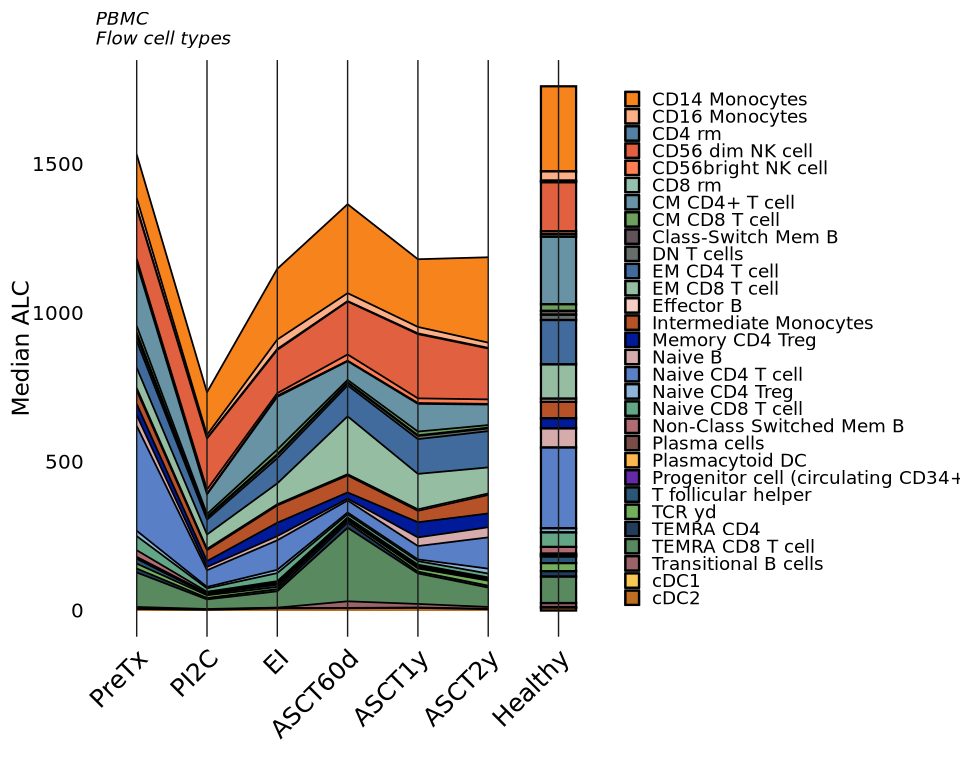

In [7]:
options(repr.plot.width = 8, repr.plot.height = 6.5)
p <- ggplot(
  plot_data,
  aes(
    x = label.visitDetails, y = V1, fill = revised_aifi_label_l2,
    group = revised_aifi_label_l2
  )
) +
  geom_area(
    data = subset(plot_data, label.visitDetails != last_visit),
    position = "stack", linewidth = 0.5, color = "black"
  ) +
  geom_col(
    data = subset(plot_data, label.visitDetails == last_visit),
    position = "stack", width = 0.5, color = "black"
  ) +
  scale_fill_manual(
    values = flow_color_map,
    breaks = names(flow_color_map)
  ) +
  scale_x_discrete(drop = TRUE) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.margin = margin(0, 10, 0, 0),
    legend.text = element_text(size = 11),
    legend.key.size = unit(0.35, "cm"),
    legend.title = element_blank(),
    axis.text.y = element_text(size = 12, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 15, color = "black"),
    panel.grid.major.x = element_line(color = "gray10", linewidth = 0.4),
    panel.grid.minor.y = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.ontop = TRUE,
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(size = 11, face = "italic")
  ) +
  labs(
    y = "Median ALC",
    x = "",
    subtitle = "PBMC \nFlow cell types"
  ) +
  guides(fill = guide_legend(title = NULL, ncol = 1, byrow = FALSE))

p

In [8]:
ggsave("../../data/figure-outputs/figure-3/fig_3a.pdf", plot = p, width = 8, height = 6.5, dpi = 200, device = cairo_pdf)